# Exploratory Data Analysis (EDA) and Text Preprocessing on IMDb Movie Reviews Dataset


## 1. Import Required Libraries

### Objective
To import the Python libraries required for data manipulation, analysis, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Upload and Load the Dataset

### Objective
To upload the IMDb dataset into Google Colab and load it into a Pandas DataFrame for further analysis.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv.zip to IMDB Dataset.csv (1).zip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
df=pd.read_csv('IMDB Dataset.csv.zip')

## 3. Display the First Five Records

### Objective
To examine the first five records of the dataset and verify that it has been loaded correctly.

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Insights

- The dataset was successfully loaded into the DataFrame.
- It contains two columns: **review** and **sentiment**.
- The **review** column contains movie review text.
- The **sentiment** column contains sentiment labels (positive and negative).
- The first five records indicate that the dataset is structured correctly.

## 4. Display the Last Five Records

### Objective
To inspect the last five records and ensure the dataset has been loaded completely.

In [5]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


### Insights

- The last five records are displayed successfully.
- The dataset appears complete without any visible truncation.
- Both columns maintain the expected format throughout the dataset.

###5. Check the Shape of the Dataset
Objective

To determine the total number of rows and columns in the dataset.

In [6]:
df.shape

(50000, 2)

## 6. View the Column Names
Objective

To identify the names of all columns present in the dataset.

In [7]:
df.columns

Index(['review', 'sentiment'], dtype='object')

##7. Get Dataset Information
Objective

To understand the structure of the dataset, including data types and missing values.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## 8. Generate Statistical Summary
Objective

To obtain a summary of the dataset.

In [9]:
df.describe(include='all')

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


## 9. Check Missing Values
Objective

To identify whether any missing values are present in the dataset.

In [10]:
df.isnull().sum()

,0
review,0
sentiment,0


##10. Check Duplicate Records
Objective

To identify duplicate entries in the dataset.

In [11]:
df.duplicated().sum()

np.int64(418)

##11. Check Sentiment Distribution
Objective

To determine the number of positive and negative reviews.


In [12]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## 12. Visualize Sentiment Distribution
Objective

To visualize the number of positive and negative movie reviews.

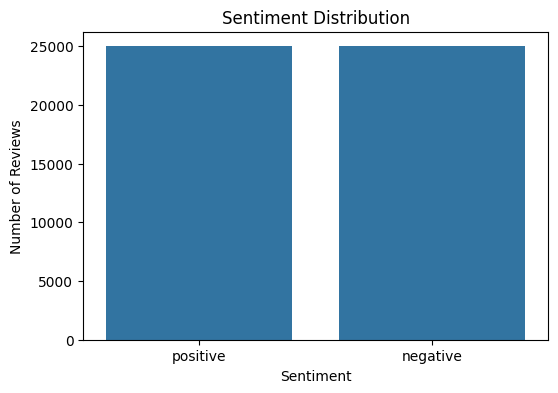

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

##13. Calculate Review Length
Objective

To calculate the number of words in each review.

In [14]:
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
df[["review","review_length"]].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


##14. Analyze Review Length Statistics
Objective

To understand the distribution of review lengths.

In [15]:
df["review_length"].describe()

,review_length
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


###15. Visualize Review Length Distribution
Objective

To visualize how review lengths are distributed.

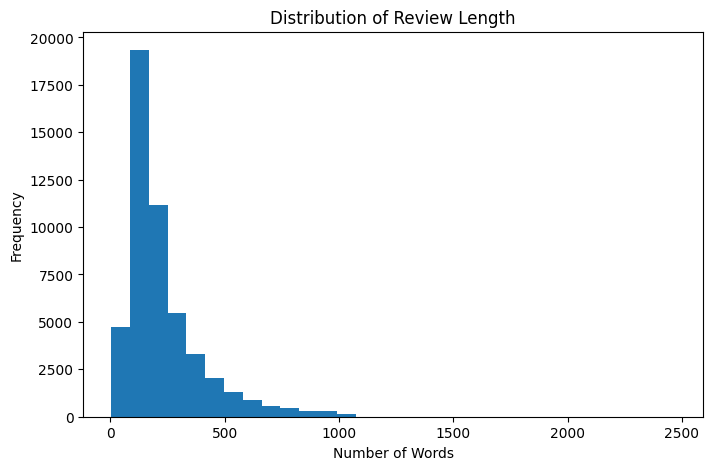

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length"], bins=30)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## 16. Word Frequency Analysis

### Objective
To identify the most frequently occurring words in the movie reviews.

In [17]:
text = " ".join(df["review"])
text = text.lower()

In [18]:
from collections import Counter
import re

In [19]:
words = re.findall(r'\b[a-z]+\b', text)
word_counts = Counter(words)
word_counts.most_common(20)

[('the', 667993),
 ('and', 324441),
 ('a', 322970),
 ('of', 289410),
 ('to', 268124),
 ('is', 211082),
 ('br', 201951),
 ('it', 190857),
 ('in', 186781),
 ('i', 175633),
 ('this', 151002),
 ('that', 143879),
 ('s', 125008),
 ('was', 95608),
 ('as', 91750),
 ('movie', 87971),
 ('for', 87471),
 ('with', 87368),
 ('but', 83554),
 ('film', 79705)]

## 17. Top 20 Most Frequent Words

### Objective
To visualize the twenty most frequently occurring words in the dataset.

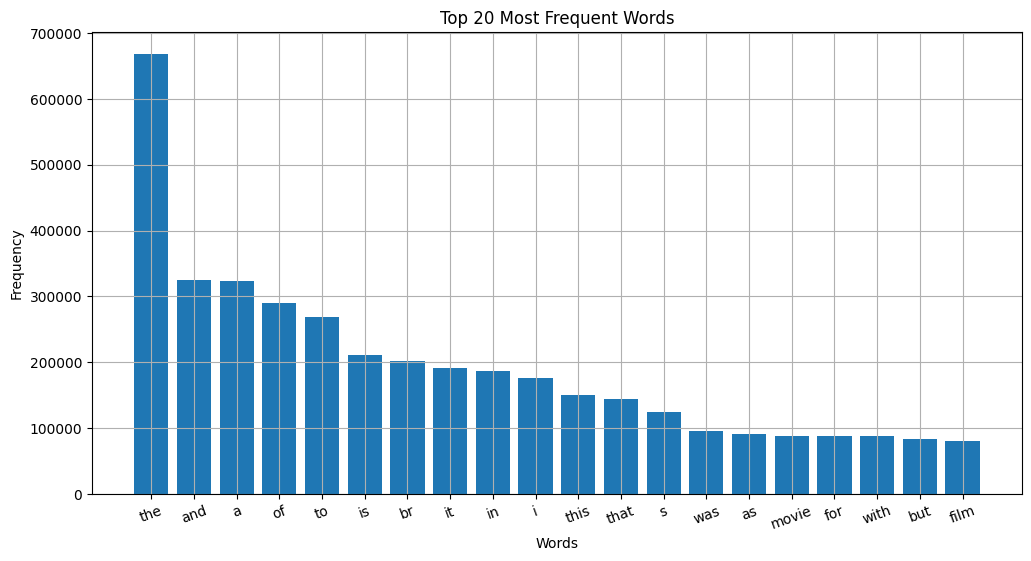

In [20]:
top20 = word_counts.most_common(20)
words = [word for word, count in top20]
counts = [count for word, count in top20]
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=20)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## 18. Word Cloud

### Objective
To visualize the most common words using a word cloud.

In [21]:
!pip install wordcloud

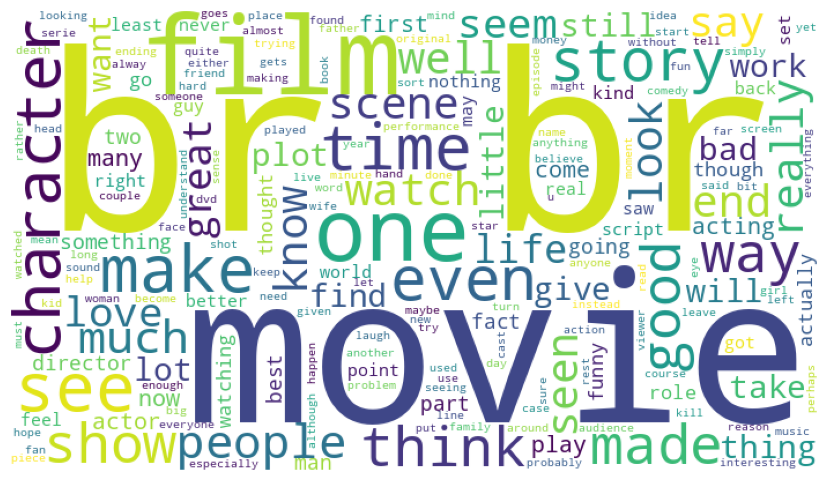

In [22]:
from wordcloud import WordCloud
wordcloud = WordCloud(
    width=700,
    height=400,
    background_color='white'
).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

##19. Bigram Analysis
###Objective

To identify the most frequently occurring two-word combinations (bigrams) in the movie reviews.

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
bigram = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)

In [24]:
X = bigram.fit_transform(df["review"])
bigram_counts = X.toarray().sum(axis=0)

In [25]:
bigram_words = bigram.get_feature_names_out()
bigram_df = pd.DataFrame({
    "Bigram": bigram_words,
    "Count": bigram_counts
})
bigram_df = bigram_df.sort_values(by="Count", ascending=False)
bigram_df

,Bigram,Count
1,br br,101188
16,ve seen,4168
2,br film,3007
3,br movie,2992
11,movie br,2358
15,special effects,2249
4,don know,2201
6,film br,2079
10,low budget,1824
9,looks like,1677


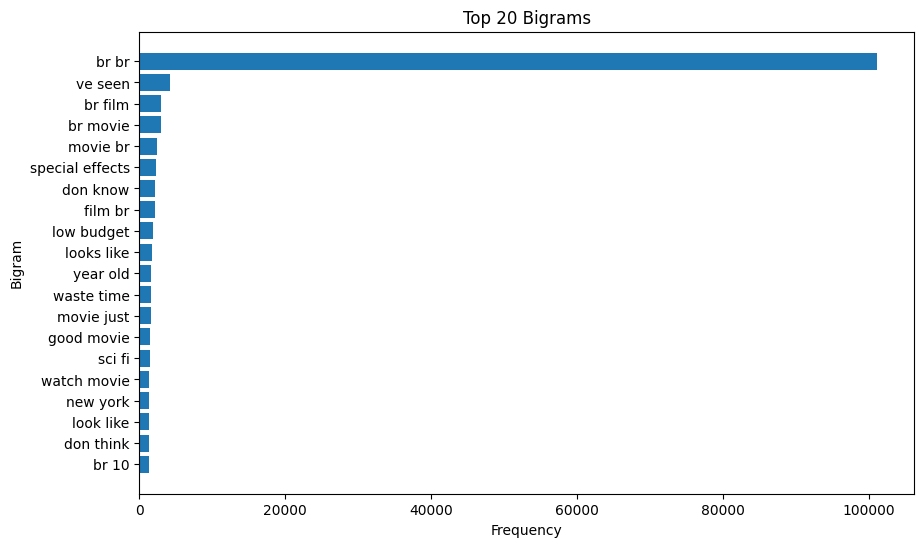

In [26]:
plt.figure(figsize=(10,6))
plt.barh(bigram_df["Bigram"], bigram_df["Count"])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Bigrams")
plt.gca().invert_yaxis()
plt.show()

##20. Trigram Analysis
###Objective

To identify the most frequently occurring three-word combinations (trigrams) in the reviews.

In [27]:
trigram = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=20)
X = trigram.fit_transform(df["review"])
trigram_counts = X.toarray().sum(axis=0)

In [28]:
trigram_words = trigram.get_feature_names_out()
trigram_df = pd.DataFrame({
    "Trigram": trigram_words,
    "Count": trigram_counts
})
trigram_df = trigram_df.sort_values(by="Count", ascending=False)
trigram_df

,Trigram,Count
3,br br film,3007
7,br br movie,2992
16,movie br br,2358
14,film br br,2079
0,br br 10,1273
11,br br story,1145
2,br br don,991
18,time br br,898
9,br br plot,833
8,br br overall,759


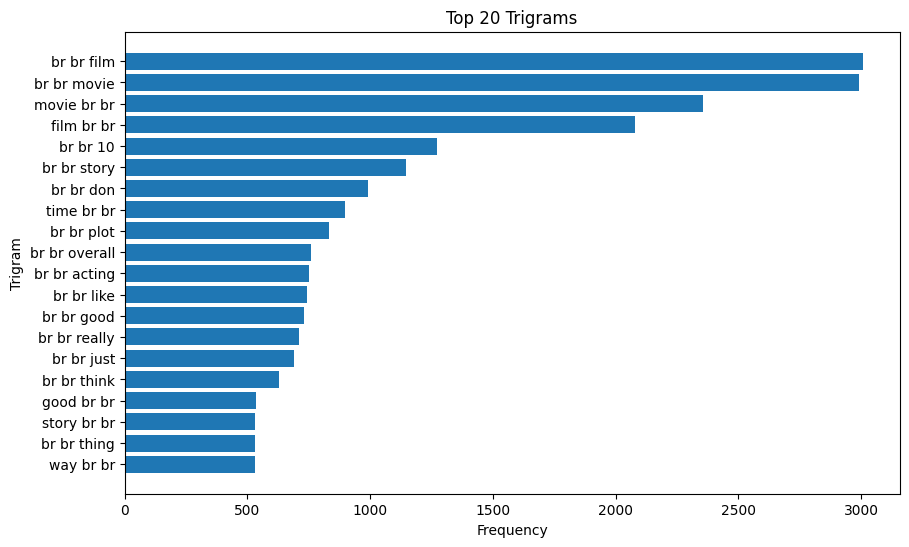

In [29]:
plt.figure(figsize=(10,6))
plt.barh(trigram_df["Trigram"], trigram_df["Count"])
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 20 Trigrams")
plt.gca().invert_yaxis()
plt.show()

## 21. Convert Text to Lowercase
###Objective

To convert all text into lowercase so that words like "Movie", "movie", and "MOVIE" are treated as the same word.

In [30]:
df["clean_review"] = df["review"].str.lower()
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production. <br /><br />the...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","petter mattei's ""love in the time of money"" is..."


In [31]:
import re
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r'<.*?>', '', x))
df["clean_review"].head()

,clean_review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."


In [32]:
import string
df["clean_review"] = df["clean_review"].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)
df["clean_review"].head()

,clean_review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...


In [33]:
df["clean_review"] = df["clean_review"].apply(lambda x: re.sub(r'\d+', '', x))
df["clean_review"].head()

,clean_review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...


In [34]:
df["clean_review"] = df["clean_review"].apply(
    lambda x: re.sub(r'http\S+|www\S+', '', x)
)
df["clean_review"].head()

,clean_review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...


In [35]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [36]:
df["clean_review"] = df["clean_review"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

In [37]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [38]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
df["tokens"] = df["clean_review"][0:5].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [39]:
df[["clean_review", "tokens"]].head()

,clean_review,tokens
0,one reviewers mentioned watching oz episode yo...,"[one, reviewers, mentioned, watching, oz, epis..."
1,wonderful little production filming technique ...,"[wonderful, little, production, filming, techn..."
2,thought wonderful way spend time hot summer we...,"[thought, wonderful, way, spend, time, hot, su..."
3,basically theres family little boy jake thinks...,"[basically, theres, family, little, boy, jake,..."
4,petter matteis love time money visually stunni...,"[petter, matteis, love, time, money, visually,..."


In [40]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [48]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
df["tokens"] = df["clean_review"].apply(word_tokenize)

df["lemmatized"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)
df[["tokens", "lemmatized"]].head()

,tokens,lemmatized
0,"[one, reviewers, mentioned, watching, oz, epis...","[one, reviewer, mentioned, watching, oz, episo..."
1,"[wonderful, little, production, filming, techn...","[wonderful, little, production, filming, techn..."
2,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ..."
4,"[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,..."


##22. Data Visualization
### Objective

To visualize important patterns and trends in the IMDb movie reviews dataset using different types of charts.

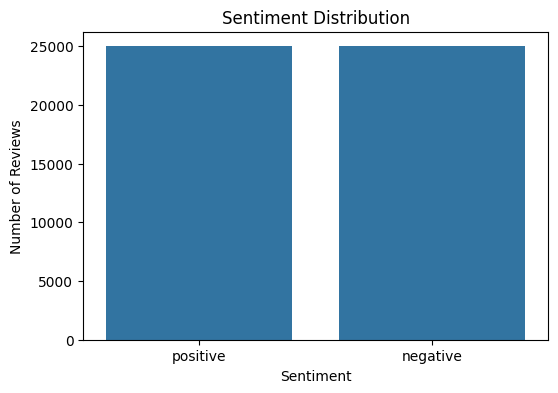

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

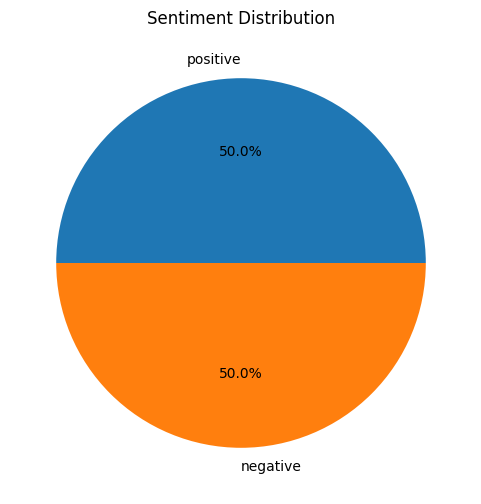

In [44]:
df["sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

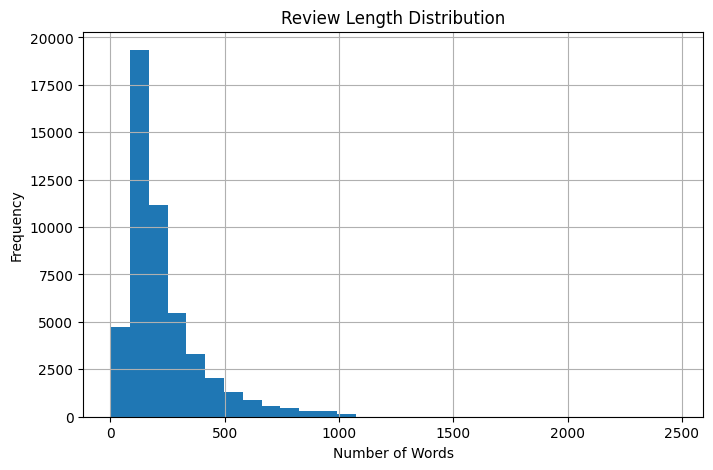

In [45]:
plt.figure(figsize=(8,5))
plt.hist(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

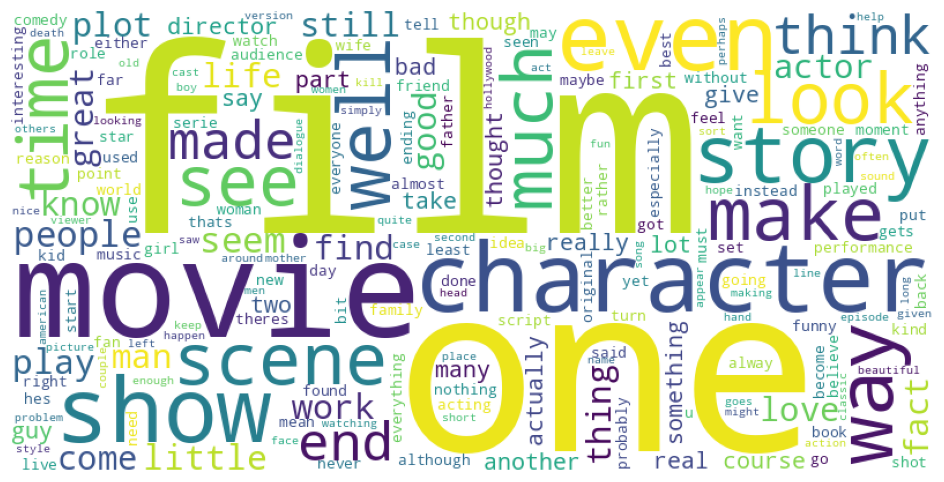

In [46]:
from wordcloud import WordCloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(" ".join(df["clean_review"]))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

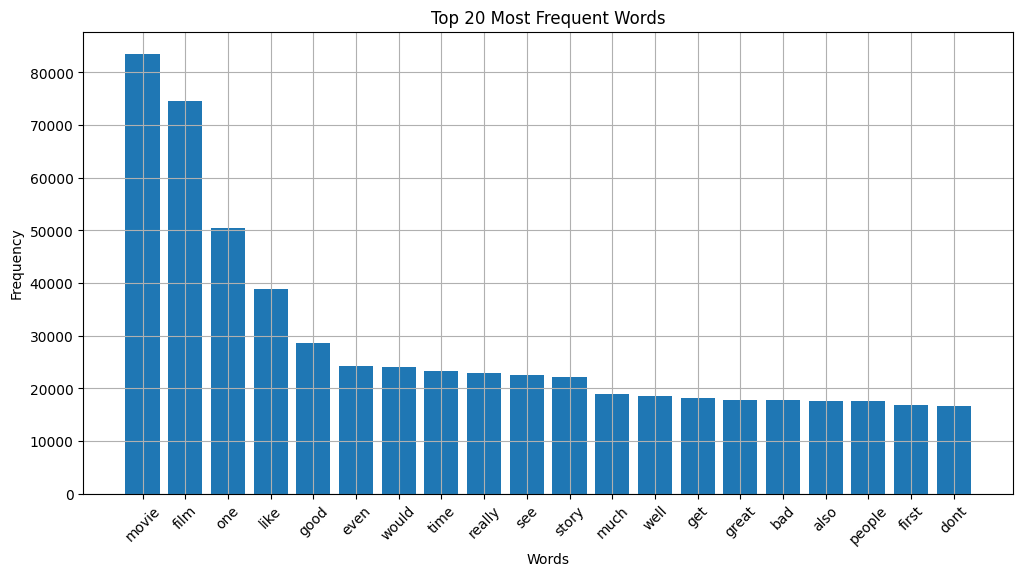

In [47]:
from collections import Counter
all_words = " ".join(df["clean_review"]).split()
word_freq = Counter(all_words)
top20 = word_freq.most_common(20)
words = [word for word, count in top20]
counts = [count for word, count in top20]
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()